In [6]:
import numpy as np
import xarray as xr
import geopandas as gpd
from rasterio.features import geometry_mask
from shapely.geometry import box
import pickle
import pandas as pd
import os
import geopandas as gpd
import netCDF4
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='.*Mean of empty slice.*')
warnings.filterwarnings('ignore', message='.*All-NaN slice.*')
warnings.filterwarnings('ignore', message='.*Degrees of freedom.*')

In [2]:
# Load from a file
with open("digihero_plz.pkl", "rb") as f:
    gdf = pickle.load(f)
gdf

,plz,note,einwohner,qkm,geometry
3,99331,99331 Geratal,4523,20.207080,"MULTIPOLYGON (((1201307.157 6567478.321, 12014..."
6,39628,39628 Bismark,3147,125.135930,"MULTIPOLYGON (((1288779.753 6907404.978, 12888..."
7,64760,64760 Oberzent,10503,165.476886,"MULTIPOLYGON (((987732.198 6378461.056, 987865..."
11,27639,27639 Wurster Nordseeküste,17093,179.924060,"MULTIPOLYGON (((944311.674 7111256.202, 944311..."
12,99707,99707 Kyffhäuserland,4281,128.579234,"MULTIPOLYGON (((1213498.934 6679730.912, 12137..."
...,...,...,...,...,...
8151,76131,76131 Karlsruhe,27382,22.226178,"MULTIPOLYGON (((933889.287 6277851.057, 934278..."
8155,76863,76863 Herxheim,10848,32.657987,"MULTIPOLYGON (((909138.945 6299369.549, 909173..."
8157,76187,76187 Karlsruhe,18005,22.162537,"MULTIPOLYGON (((923815.93 6277781.974, 924972...."
8168,75339,75339 Höfen an der Enz,1619,9.081549,"MULTIPOLYGON (((951784.251 6239600.076, 952028..."


In [8]:
import numpy as np
import xarray as xr
import geopandas as gpd
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
from shapely.geometry import box, Point
import pandas as pd
import warnings

def _process_single_area(idx, row, geom, lons, lats, var_data, n_timesteps, use_geometry_mask):
    """
    Helper function to process a single GeoDataFrame row.
    This is called in parallel by joblib.
    """
    # Suppress NaN warnings
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    
    # Method 1: Using rasterio's geometry_mask (recommended for speed)
    if use_geometry_mask:
        bounds = (lons.min(), lats.min(), lons.max(), lats.max())
        transform = from_bounds(*bounds, lons.shape[1], lats.shape[0])
        mask = geometry_mask([geom], out_shape=lons.shape, transform=transform, invert=True)
    
    # Method 2: Point-in-polygon (more flexible but slower)
    else:
        mask = np.zeros(lons.shape, dtype=bool)
        for i in range(lons.shape[0]):
            for j in range(lons.shape[1]):
                point = Point(lons[i, j], lats[i, j])
                mask[i, j] = geom.contains(point)
    
    # Extract values for all timesteps where mask is True
    if mask.sum() > 0:
        extracted_values = var_data[:, mask]
        
        # Calculate statistics for EACH TIMESTEP
        stats_list = []
        for t in range(n_timesteps):
            values_t = extracted_values[t, :]
            stats_list.append({
                'Month': t+1,
                'mean': np.nanmean(values_t),
                'median': np.nanmedian(values_t),
                'std': np.nanstd(values_t),
                'min': np.nanmin(values_t),
                'max': np.nanmax(values_t),
                'n_pixels': mask.sum(),
            })
        stats = pd.DataFrame(stats_list)
    else:
        extracted_values = np.array([]).reshape(var_data.shape[0], 0)
        stats = pd.DataFrame({
            'Month': range(1,n_timesteps+1),
            'mean': [np.nan] * n_timesteps,
            'median': [np.nan] * n_timesteps,
            'std': [np.nan] * n_timesteps,
            'min': [np.nan] * n_timesteps,
            'max': [np.nan] * n_timesteps,
            'n_pixels': [0] * n_timesteps,
        })
    
    return row.plz, {
        'stats': stats,
        'note': row.note,
        'qkm': row.qkm
    }


def extract_netcdf_by_areas(nc_file, var_name, gdf, use_geometry_mask=True, n_jobs=-1):
    """
    Extract NetCDF variable values that fall within GeoDataFrame polygon areas.
    Uses parallel processing with joblib to speed up computation.
    
    Parameters:
    -----------
    nc_file : str
        Path to NetCDF file
    var_name : str
        Name of variable to extract
    gdf : GeoDataFrame
        GeoDataFrame with polygon geometries in WGS84
    use_geometry_mask : bool
        If True, uses rasterio's geometry_mask (faster for complex geometries)
        If False, uses point-in-polygon checks (more flexible)
    n_jobs : int
        Number of jobs for parallel processing
        -1 = use all CPUs (default), positive int = number of CPUs to use

    """
    from joblib import Parallel, delayed
    
    # Load NetCDF
    ds = xr.open_dataset(nc_file)
    lons = ds['Longitude'][:].values
    lats = ds['Latitude'][:].values
    var_data = ds.variables[var_name][:].values  # shape (12, 2400, 2400)
    n_timesteps = var_data.shape[0]
    
    # Ensure GeoDataFrame is in WGS84
    if gdf.crs != 'EPSG:4326':
        gdf = gdf.to_crs('EPSG:4326')
    
    # Process all areas in parallel
    results_list = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_process_single_area)(
            idx, row, row.geometry, lons, lats, var_data, n_timesteps, use_geometry_mask
        )
        for idx, row in gdf.iterrows()
    )

    # Convert results list back to dictionary
    results = {idx: res for idx, res in results_list}
    
    ds.close()
    return results


nc_file = r"C:\code\CLUES\playground\modis\2013.nc"
print(f"Processing file: {nc_file}")

ds = netCDF4.Dataset(nc_file)

variablesOI = {
    var_name: var.dimensions
    for var_name, var in ds.variables.items()
    if var_name not in [
        'longitude', 'latitude', 'valid_time',
        'expver', 'number', 'model_level',
        'Longitude', 'Latitude','time'
    ]
}

var_name = list(variablesOI.keys())[0]

# Load your files
with open("digihero_plz.pkl", "rb") as f:
    gdf = pickle.load(f)

# Extract values - uses all CPUs by default
# Set n_jobs=4 to use 4 CPUs, n_jobs=1 for serial processing
results = extract_netcdf_by_areas(nc_file, var_name, gdf, use_geometry_mask=True, n_jobs=-1)

# Access results for each area
for area_idx, area_results in results.items():
    print(f"\n{'='*60}")
    print(f"Area {area_idx}")
    print(f"{'='*60}")
    print(area_results['note'])
    print(area_results['stats'])
    print(area_results['qkm'])

Processing file: C:\code\CLUES\playground\modis\2013.nc


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   


Area 99331
99331 Geratal
    Month      mean  median       std     min     max  n_pixels
0       1  0.392110  0.3705  0.089626  0.2466  0.6360        19
1       2  0.529758  0.5331  0.073103  0.4197  0.6696        19
2       3  0.466484  0.4625  0.034411  0.4180  0.5454        19
3       4  0.465000  0.4708  0.028943  0.4206  0.5044        19
4       5  0.506084  0.5001  0.045971  0.4254  0.6352        19
5       6  0.781921  0.7859  0.024185  0.7148  0.8341        19
6       7  0.821142  0.8243  0.025530  0.7799  0.8577        19
7       8  0.769205  0.7809  0.065380  0.6412  0.8533        19
8       9  0.717616  0.7244  0.093120  0.5637  0.8532        19
9      10  0.743937  0.7516  0.061864  0.6551  0.8336        19
10     11  0.730884  0.7219  0.050303  0.6305  0.8090        19
11     12  0.645805  0.6488  0.026035  0.5949  0.6891        19
20.20708

Area 39628
39628 Bismark
    Month      mean  median       std     min     max  n_pixels
0       1  0.571634  0.5655  0.070607  0.41

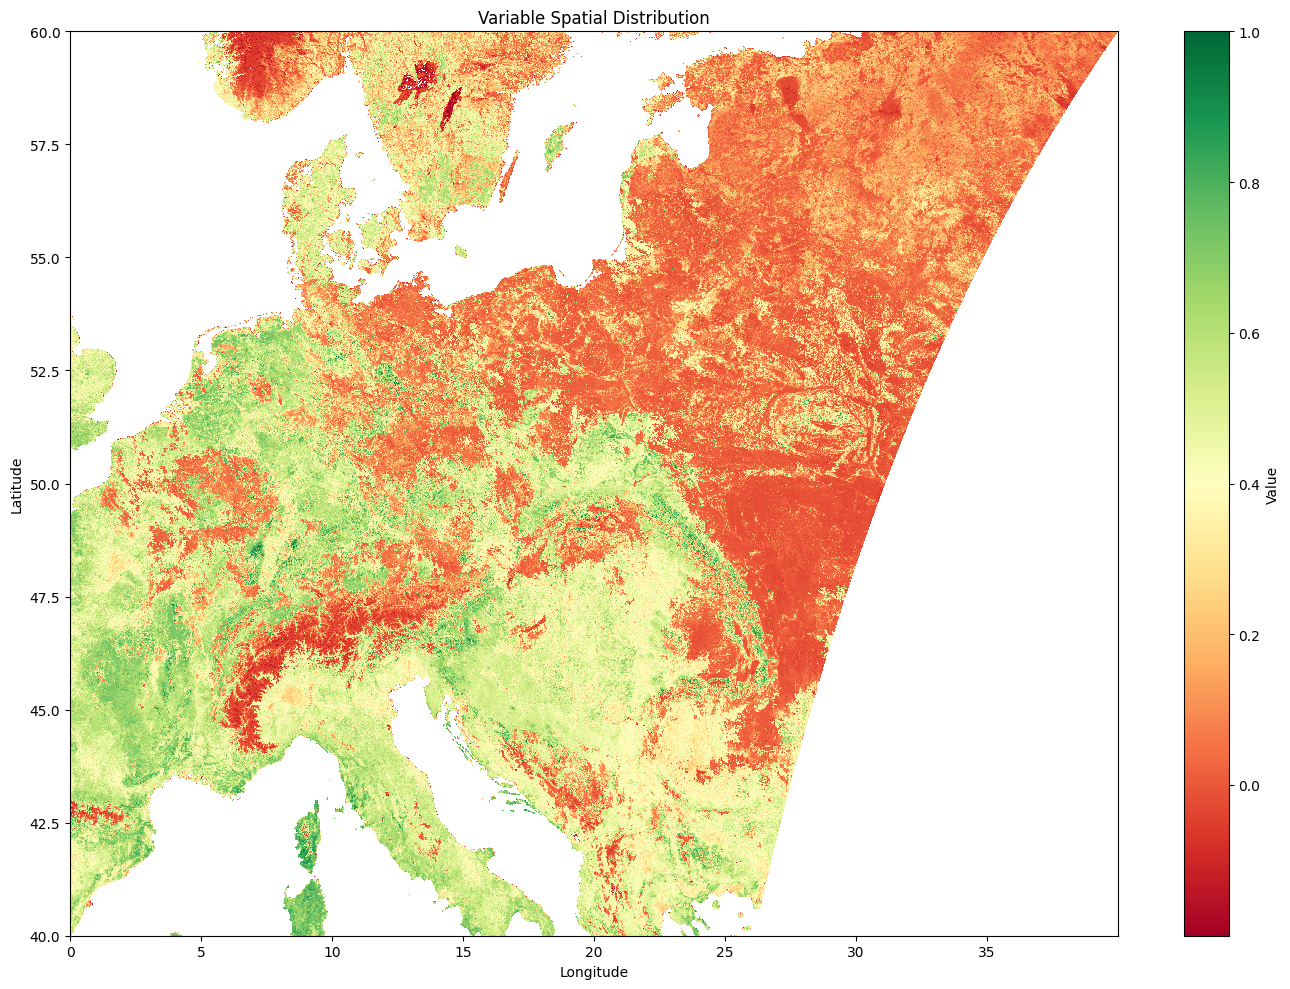

In [7]:
var = ds.variables[var_name][1,:,:]
lons = ds['Longitude'][:]
lats = ds['Latitude'][:]

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.pcolormesh(lons, lats, var, cmap='RdYlGn', shading='auto')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Variable Spatial Distribution')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Value')

plt.tight_layout()
plt.show()